# AIIMS ECG-PPG Sync Debug Notebook (fixed)

### Why this version
- The earlier approach used `argmax` in a broad `[0.1, 0.8] s` window after every R-peak.
- That often picks a late wave / motion artifact, producing unrealistically high PTT and floor/ceiling clipping.
- Here, we use:
  1. stable drift correction using relative-time anchor mapping,
  2. robust local peak detection (`find_peaks` + prominence),
  3. physiological gating of PTT.

### Physiological target window used
From common ECG-to-finger-PPG transit timing reported in literature and device studies, practical adult ranges are often around **0.15-0.35 s**; we use a conservative acceptance gate of **0.10-0.45 s**.


In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import neurokit2 as nk

## 1) Keep the same paths and variable names


In [2]:
# ppg_csv = Path("1/Polar/E90F3223/Fateh Singh_108505253_E90F3223_13ppg.csv")
# ecg_csv = Path("1/Holter/06-08-2025.csv")
# meta_data_csv = Path("1/Polar/E90F3223/Fateh Singh_108505253_E90F3223_13metaData.csv")

# ppg_csv_device_2 = Path("1/Polar/E9124620/Fateh Singh_108505253_E9124620_14ppg.csv")


In [3]:
ppg_csv = Path("1/Polar/E90F3223/Fateh Singh_108505253_E90F3223_13ppg.csv")
ecg_csv = Path("1/Holter/06-08-2025.csv")
ppg_csv_device_2 = Path("1/Polar/E9124620/Fateh Singh_108505253_E9124620_14ppg.csv")


def build_device_file_bundle(ppg_path):
    stem = ppg_path.stem
    if not stem.endswith("ppg"):
        raise ValueError(f"Unexpected PPG filename format: {ppg_path.name}")

    prefix = stem[:-3]
    return {
        "ppg": ppg_path,
        "metaData": ppg_path.with_name(f"{prefix}metaData.csv"),
        "accelerometer": ppg_path.with_name(f"{prefix}accelerometer.csv"),
        "gyroscope": ppg_path.with_name(f"{prefix}gyroscope.csv"),
        "magnetometer": ppg_path.with_name(f"{prefix}magnetometer.csv"),
    }


device_1_files = build_device_file_bundle(ppg_csv)
device_2_files = build_device_file_bundle(ppg_csv_device_2)

In [4]:
fs_ecg = 200

def load_device_streams(device_files, device_label):
    device_data = {
        "label": device_label,
        "paths": device_files,
        "ppg_df": pd.read_csv(device_files["ppg"]),
        "meta_df": pd.read_csv(device_files["metaData"]),
        "sensor_dfs": {},
    }

    for sensor_name in ["accelerometer", "gyroscope", "magnetometer"]:
        sensor_path = device_files[sensor_name]
        if sensor_path.exists():
            device_data["sensor_dfs"][sensor_name] = pd.read_csv(sensor_path)
        else:
            print(f"Warning: {device_label} {sensor_name} file not found at {sensor_path}; skipping sync for this sensor.")

    return device_data


device_1_data = load_device_streams(device_1_files, "Device 1 (E90F3223)")
device_2_data = load_device_streams(device_2_files, "Device 2 (E9124620)")

ecg_df = pd.read_csv(ecg_csv)
ppg_df = device_1_data["ppg_df"]
ppg_df_device_2 = device_2_data["ppg_df"]
meta_df = device_1_data["meta_df"]
meta_df_device_2 = device_2_data["meta_df"]

ecg_signal = ecg_df.iloc[:, 2].to_numpy()
ppg_signal = ppg_df.iloc[:, 1].to_numpy()
ppg_signal_device_2 = ppg_df_device_2.iloc[:, 1].to_numpy()

# derive true sampling rates from timestamps
fs_ppg = 1.0 / np.mean(np.diff(ppg_df["time"].to_numpy()) / 1e9)
fs_ppg_device_2 = 1.0 / np.mean(np.diff(ppg_df_device_2["time"].to_numpy()) / 1e9)

print(f"ECG fs={fs_ecg:.3f} Hz | PPG1 fs={fs_ppg:.3f} Hz | PPG2 fs={fs_ppg_device_2:.3f} Hz")

for device_data in [device_1_data, device_2_data]:
    print(f"Loaded metadata columns for {device_data['label']}:", ", ".join(device_data["meta_df"].columns.tolist()))
    for sensor_name, sensor_df in device_data["sensor_dfs"].items():
        sensor_fs = 1.0 / np.mean(np.diff(sensor_df["time"].to_numpy(np.int64)) / 1e9)
        print(f"{device_data['label']} | {sensor_name.title()} fs={sensor_fs:.3f} Hz | samples={len(sensor_df)}")

ECG fs=200.000 Hz | PPG1 fs=175.237 Hz | PPG2 fs=175.989 Hz
Loaded metadata columns for Device 1 (E90F3223): deviceName, deviceID, deviceFixedDelay, HR_SAMPLE_POINTS, ACC_SAMPLE_RATE, ACC_SAMPLE_POINTS, ACC_RESOLUTION, ACC_RANGE, ACC_CHANNELS, GYRO_SAMPLE_RATE, GYRO_SAMPLE_POINTS, GYRO_RESOLUTION, GYRO_RANGE, GYRO_CHANNELS, MAGN_SAMPLE_RATE, MAGN_SAMPLE_POINTS, MAGN_RESOLUTION, MAGN_RANGE, MAGN_CHANNELS, PPG_SAMPLE_RATE, PPG_SAMPLE_POINTS, PPG_RESOLUTION, PPG_RANGE, PPG_CHANNELS
Device 1 (E90F3223) | Accelerometer fs=380.136 Hz | samples=58936132
Device 1 (E90F3223) | Gyroscope fs=380.136 Hz | samples=58936086
Device 1 (E90F3223) | Magnetometer fs=99.683 Hz | samples=15454817
Loaded metadata columns for Device 2 (E9124620): deviceName, deviceID, deviceFixedDelay, HR_SAMPLE_POINTS, ACC_SAMPLE_RATE, ACC_SAMPLE_POINTS, ACC_RESOLUTION, ACC_RANGE, ACC_CHANNELS, GYRO_SAMPLE_RATE, GYRO_SAMPLE_POINTS, GYRO_RESOLUTION, GYRO_RANGE, GYRO_CHANNELS, MAGN_SAMPLE_RATE, MAGN_SAMPLE_POINTS, MAGN_RESOLU

In [5]:
# ecg_csv = Path("1_Ramesh/Holter/24_06_2025.csv")
# ppg_csv = Path("1_Ramesh/Polar/E90F3223/Ramesh_107855607_E90F3223_1ppg.csv")
# meta_data_csv = Path("1_Ramesh/Polar/E90F3223/Ramesh_107855607_E90F3223_1metaData.csv")
# ppg_csv_device_2 = Path("1_Ramesh/Polar/E9124620/Ramesh_107855607_E9124620_2ppg.csv")

In [6]:
# fs_ecg = 200

# ppg_df = pd.read_csv(ppg_csv)
# ecg_df = pd.read_csv(ecg_csv)
# ppg_df_device_2 = pd.read_csv(ppg_csv_device_2)

# ecg_signal = ecg_df.iloc[:, 2].to_numpy()
# ppg_signal = ppg_df.iloc[:, 1].to_numpy()
# ppg_signal_device_2 = ppg_df_device_2.iloc[:, 1].to_numpy()

# # derive true PPG sampling rates from timestamps
# fs_ppg = 1.0 / np.mean(np.diff(ppg_df["time"].to_numpy()) / 1e9)
# fs_ppg_device_2 = 1.0 / np.mean(np.diff(ppg_df_device_2["time"].to_numpy()) / 1e9)

# print(f"ECG fs={fs_ecg:.3f} Hz | PPG1 fs={fs_ppg:.3f} Hz | PPG2 fs={fs_ppg_device_2:.3f} Hz")


## 2) Keep the same sync anchor index values


In [7]:
# Device 1 (E90F3223) anchors - SAME as original notebook
ppg_idx_1 = 14343639
ppg_idx_2 = 27155637

# ECG anchors - SAME as original notebook
ecg_idx_1 = 16331017
ecg_idx_2 = 30954051

# Device 2 (E9124620) anchors - SAME as original notebook
ppg_idx_1_device_2 = 14403716
ppg_idx_2_device_2 = 27272110


In [8]:
# #Ramesh PPG device -1
# ppg_idx_1 = 260102
# ppg_idx_2 = 25045342

# ecg_idx_1 = 3264
# ecg_idx_2 = 28299092

# ppg_idx_1_device_2 = 261228
# ppg_idx_2_device_2 = 25156320

## 3) Signal cleaning and R-peak detection


In [ ]:
ecg_clean = nk.ecg_clean(ecg_signal, sampling_rate=fs_ecg, method="neurokit")
_, ecg_info = nk.ecg_peaks(ecg_clean, sampling_rate=fs_ecg)
rpeaks = ecg_info["ECG_R_Peaks"]

ppg_clean = nk.ppg_clean(ppg_signal, sampling_rate=fs_ppg, method="elgendi")
ppg_clean_device_2 = nk.ppg_clean(ppg_signal_device_2, sampling_rate=fs_ppg_device_2, method="elgendi")

print("R-peaks:", len(rpeaks))


## 4) Stable clock-map fit (relative-time domain)


In [10]:
def fit_linear_clock_map_from_anchors(ppg_time_ns, ecg_time_ns, ppg_anchor_idx, ecg_anchor_idx):
    ppg_anchor_ns = ppg_time_ns[np.asarray(ppg_anchor_idx, dtype=int)]
    ecg_anchor_ns = ecg_time_ns[np.asarray(ecg_anchor_idx, dtype=int)]

    t_ref_ns = int(min(ppg_anchor_ns.min(), ecg_anchor_ns.min()))
    t_ppg_rel = (ppg_anchor_ns - t_ref_ns) / 1e9
    t_ecg_rel = (ecg_anchor_ns - t_ref_ns) / 1e9

    a, b_rel = np.polyfit(t_ppg_rel, t_ecg_rel, deg=1)
    return {
        "a": a,
        "b_rel": b_rel,
        "t_ref_ns": t_ref_ns,
        "ppg_anchor_ns": ppg_anchor_ns,
        "ecg_anchor_ns": ecg_anchor_ns,
    }


def resample_ppg_to_ecg_domain_stable(ppg_time_ns, ppg_clean_sig, ecg_time_ns, ppg_anchor_idx, ecg_anchor_idx):
    map_info = fit_linear_clock_map_from_anchors(ppg_time_ns, ecg_time_ns, ppg_anchor_idx, ecg_anchor_idx)

    t_ref_ns = map_info["t_ref_ns"]
    a = map_info["a"]
    b_rel = map_info["b_rel"]

    t_ppg_rel = (ppg_time_ns.astype(np.int64) - t_ref_ns) / 1e9
    t_ecg_rel = (ecg_time_ns.astype(np.int64) - t_ref_ns) / 1e9

    # invert map: t_ecg_rel = a * t_ppg_rel + b_rel
    t_ecg_as_ppg_rel = (t_ecg_rel - b_rel) / a
    ppg_resampled = np.interp(t_ecg_as_ppg_rel, t_ppg_rel, ppg_clean_sig) # np.interp(query_time, known_time, known_signal)

    return ppg_resampled, map_info


## 5) ECG-guided PPG peak detection (no weighted scoring)

Key change vs the previous version:
- do **not** rank candidates with a weighted score based on delay/prominence/amplitude.
- detect candidate peaks in a physiologic ECG→PPG window and choose the **earliest sufficiently prominent peak**.

This makes the detector depend on explicit physiologic constraints and local peak shape only, rather than on a tunable weighted scoring mechanism.


In [ ]:
def robust_ecg_guided_ppg_peaks(
    rpeak_indices,
    ppg_resampled,
    fs_ecg,
    min_delay=0.10,
    max_delay=0.46,
    min_prom_factor=0.25,
    min_distance_sec=0.08,
):
    """
    ECG-guided PPG peak detection without weighted candidate scoring.

    Strategy:
    1) search only inside a physiologic ECG→PPG delay window,
    2) detect locally prominent PPG peaks,
    3) choose the earliest sufficiently prominent candidate,
       which is typically the systolic peak following the ECG beat.
    """
    ppg_peak_indices = []
    matched_rpeaks = []

    min_s = int(min_delay * fs_ecg)
    max_s = int(max_delay * fs_ecg)
    min_distance = max(1, int(min_distance_sec * fs_ecg))

    for r_idx in np.asarray(rpeak_indices, dtype=int):
        start_idx = r_idx + min_s
        end_idx = r_idx + max_s
        if start_idx < 0 or end_idx >= len(ppg_resampled):
            continue

        window = np.asarray(ppg_resampled[start_idx:end_idx], dtype=float)
        if len(window) < 5 or np.all(~np.isfinite(window)):
            continue

        amp = np.nanpercentile(window, 95) - np.nanpercentile(window, 5)
        min_prom = max(1e-6, float(min_prom_factor) * amp)

        cand, props = find_peaks(window, distance=min_distance, prominence=min_prom)
        if len(cand) == 0:
            continue

        prominences = props.get("prominences", np.zeros(len(cand), dtype=float))
        strong_mask = prominences >= np.nanmedian(prominences)
        if np.any(strong_mask):
            cand = cand[strong_mask]

        best = int(cand[0])
        ppg_idx = start_idx + best
        ptt = (ppg_idx - r_idx) / fs_ecg

        if min_delay <= ptt <= max_delay:
            ppg_peak_indices.append(ppg_idx)
            matched_rpeaks.append(r_idx)

    return np.asarray(ppg_peak_indices, dtype=int), np.asarray(matched_rpeaks, dtype=int)


def mad_outlier_mask(x, thresh=5.0):
    x = np.asarray(x)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-9
    z = 0.6745 * (x - med) / mad
    return np.abs(z) <= thresh


## 6) Device 1: before/after drift correction and final PTT


In [12]:
# BEFORE drift correction (naive interpolation in absolute timestamp domain)
t_ppg_abs = ppg_df["time"].to_numpy(np.int64) / 1e9
t_ecg_abs = ecg_df["time"].to_numpy(np.int64) / 1e9
ppg_abs_to_ecg = np.interp(t_ecg_abs, t_ppg_abs, ppg_clean)

ppg_pk_before, r_before = robust_ecg_guided_ppg_peaks(rpeaks, ppg_abs_to_ecg, fs_ecg)
ptt_before = (ppg_pk_before - r_before) / fs_ecg

# AFTER drift correction
ppg_resampled_device_1_stable, map_device_1 = resample_ppg_to_ecg_domain_stable(
    ppg_df["time"].to_numpy(np.int64),
    ppg_clean,
    ecg_df["time"].to_numpy(np.int64),
    [ppg_idx_1, ppg_idx_2],
    [ecg_idx_1, ecg_idx_2],
)

ppg_pk_after, r_after = robust_ecg_guided_ppg_peaks(rpeaks, ppg_resampled_device_1_stable, fs_ecg)
ptt_after = (ppg_pk_after - r_after) / fs_ecg

# remove residual outliers
mask_after = mad_outlier_mask(ptt_after, thresh=5.0)
ptt_after_clean = ptt_after[mask_after]
beat_time_after = r_after[mask_after] / fs_ecg

offset_device_1_sec = map_device_1["b_rel"]
offset_device_1_ns = offset_device_1_sec * 1e9
print("Device1 map a:", map_device_1["a"], " drift ppm:", (map_device_1["a"] - 1) * 1e6)
print("Device1 offset b_rel (s):", offset_device_1_sec, " | offset (ns):", offset_device_1_ns)
print("PTT before mean±std:", np.mean(ptt_before), np.std(ptt_before), "N=", len(ptt_before))
print("PTT after mean±std :", np.mean(ptt_after_clean), np.std(ptt_after_clean), "N=", len(ptt_after_clean))

Device1 map a: 0.9999858038331741  drift ppm: -14.196166825852785
Device1 offset b_rel (s): -162.8778024787272  | offset (ns): -162877802478.7272
PTT before mean±std: 0.2900794482981126 0.06721680413913068 N= 74388
PTT after mean±std : 0.258161488029708 0.061997680064296526 N= 60859


In [ ]:
def segmentwise_ptt_slopes(time_sec, ptt_sec, window_sec=60.0, step_sec=60.0, min_points=5):
    """Compute linear PTT-vs-time slope per segment.

    Returns
    -------
    centers : np.ndarray
        Segment center times in seconds.
    slopes : np.ndarray
        Linear-fit slope (sec/sec) for each valid segment.
    """
    time_sec = np.asarray(time_sec, dtype=float)
    ptt_sec = np.asarray(ptt_sec, dtype=float)

    if time_sec.size == 0 or ptt_sec.size == 0:
        return np.array([], dtype=float), np.array([], dtype=float)

    finite_mask = np.isfinite(time_sec) & np.isfinite(ptt_sec)
    time_sec = time_sec[finite_mask]
    ptt_sec = ptt_sec[finite_mask]
    if time_sec.size == 0:
        return np.array([], dtype=float), np.array([], dtype=float)

    t_start = float(np.min(time_sec))
    t_end = float(np.max(time_sec))

    centers = []
    slopes = []
    left = t_start
    while left + window_sec <= t_end + 1e-12:
        right = left + window_sec
        mask = (time_sec >= left) & (time_sec < right)
        if np.count_nonzero(mask) >= min_points:
            t_win = time_sec[mask]
            p_win = ptt_sec[mask]
            slope, _ = np.polyfit(t_win, p_win, 1)
            centers.append(left + window_sec / 2.0)
            slopes.append(float(slope))
        left += step_sec

    return np.asarray(centers, dtype=float), np.asarray(slopes, dtype=float)


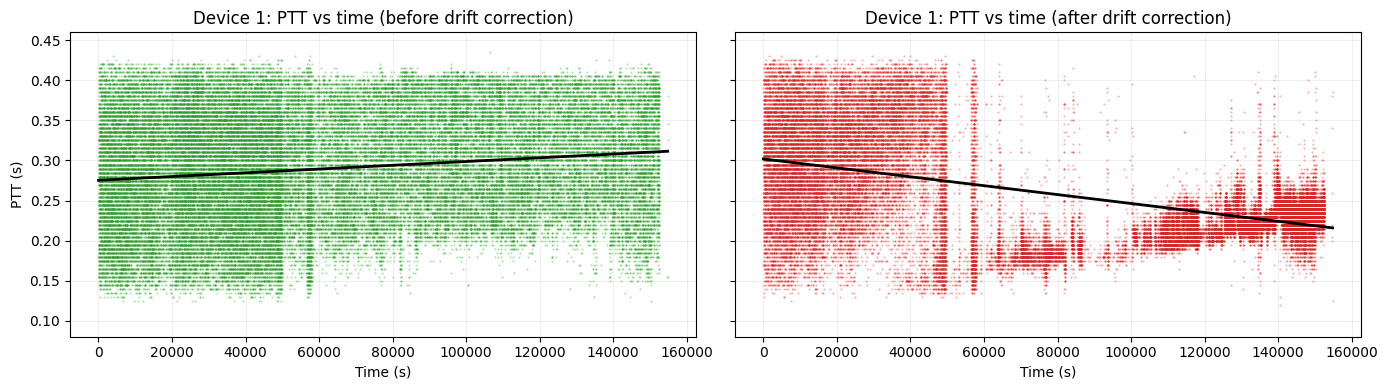

Slope before: 2.341e-07 sec/sec
Slope after : -5.559e-07 sec/sec


In [13]:
# 60-second segment-wise trend check for both devices (before and after drift correction)


def plot_segmentwise_ptt(device_label, beat_time_before, ptt_before, beat_time_after, ptt_after, y_limits=(0.08, 0.46)):
    seg_t_before, seg_slopes_before = segmentwise_ptt_slopes(
        beat_time_before, ptt_before, window_sec=60.0, step_sec=60.0
    )
    seg_t_after, seg_slopes_after = segmentwise_ptt_slopes(
        beat_time_after, ptt_after, window_sec=60.0, step_sec=60.0
    )

    coef_before = [np.nanmedian(seg_slopes_before), np.nan] if len(seg_slopes_before) else [np.nan, np.nan]
    coef_after = [np.nanmedian(seg_slopes_after), np.nan] if len(seg_slopes_after) else [np.nan, np.nan]

    fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    ax[0].plot(beat_time_before, ptt_before, '.', ms=1, alpha=0.35, color='tab:green')
    ax[0].set_title(f"{device_label}: PTT vs time (before drift correction)")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("PTT (s)")
    ax[0].set_ylim(*y_limits)
    ax[0].grid(alpha=0.2)

    ax[1].plot(beat_time_after, ptt_after, '.', ms=1, alpha=0.35, color='tab:red')
    ax[1].set_title(f"{device_label}: PTT vs time (after drift correction)")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylim(*y_limits)
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(1, 2, figsize=(14, 3), sharey=True)
    ax2[0].plot(seg_t_before, seg_slopes_before, '-o', ms=3, lw=1.2, color='tab:green')
    ax2[0].axhline(np.nanmedian(seg_slopes_before), color='k', ls='--', lw=1)
    ax2[0].set_title(f'{device_label} Before: 60s segment slopes')
    ax2[0].set_xlabel('Time (s)')
    ax2[0].set_ylabel('Slope (sec/sec)')
    ax2[0].grid(alpha=0.2)

    ax2[1].plot(seg_t_after, seg_slopes_after, '-o', ms=3, lw=1.2, color='tab:red')
    ax2[1].axhline(np.nanmedian(seg_slopes_after), color='k', ls='--', lw=1)
    ax2[1].set_title(f'{device_label} After: 60s segment slopes')
    ax2[1].set_xlabel('Time (s)')
    ax2[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    print(
        f"{device_label} 60s segment slope before (median): {coef_before[0]:.3e} sec/sec | segments={len(seg_slopes_before)}"
    )
    print(
        f"{device_label} 60s segment slope after  (median): {coef_after[0]:.3e} sec/sec | segments={len(seg_slopes_after)}"
    )


# Device 1
plot_segmentwise_ptt("Device 1", beat_time_before, ptt_before, beat_time_after, ptt_after_clean)

# Device 2 (runs when Device 2 variables are available)
if all(name in globals() for name in ["beat_time_before_d2", "ptt_before_d2", "beat_time_d2", "ptt_d2_clean"]):
    plot_segmentwise_ptt("Device 2", beat_time_before_d2, ptt_before_d2, beat_time_d2, ptt_d2_clean)
else:
    print("Device 2 60s graph skipped: run Device 2 processing cells first, then re-run this cell.")




## 7) Device 2 (same strategy, same anchor variables)


In [14]:
ppg_resampled_device_2_stable, map_device_2 = resample_ppg_to_ecg_domain_stable(
    ppg_df_device_2["time"].to_numpy(np.int64),
    ppg_clean_device_2,
    ecg_df["time"].to_numpy(np.int64),
    [ppg_idx_1_device_2, ppg_idx_2_device_2],
    [ecg_idx_1, ecg_idx_2],
)

ppg_pk_d2, r_d2 = robust_ecg_guided_ppg_peaks(rpeaks, ppg_resampled_device_2_stable, fs_ecg)
ptt_d2 = (ppg_pk_d2 - r_d2) / fs_ecg
mask_d2 = mad_outlier_mask(ptt_d2, thresh=5.0)
ptt_d2_clean = ptt_d2[mask_d2]

offset_device_2_sec = map_device_2["b_rel"]
offset_device_2_ns = offset_device_2_sec * 1e9
print("Device2 map a:", map_device_2["a"], " drift ppm:", (map_device_2["a"] - 1) * 1e6)
print("Device2 offset b_rel (s):", offset_device_2_sec, " | offset (ns):", offset_device_2_ns)
print("Device2 PTT mean±std:", np.mean(ptt_d2_clean), np.std(ptt_d2_clean), "N=", len(ptt_d2_clean))

Device2 map a: 0.9999866514136144  drift ppm: -13.348586385575345
Device2 offset b_rel (s): -161.83449781436727  | offset (ns): -161834497814.36728
Device2 PTT mean±std: 0.22367410269922125 0.0270651149538866 N= 51237


In [15]:
def map_timebase_to_source_rel(target_time_ns, map_info):
    t_ref_ns = map_info["t_ref_ns"]
    a = map_info["a"]
    b_rel = map_info["b_rel"]

    target_time_rel = (np.asarray(target_time_ns, dtype=np.int64) - t_ref_ns) / 1e9
    return (target_time_rel - b_rel) / a


def resample_with_known_clock_map(source_time_ns, source_values, ecg_time_ns, map_info):
    t_ref_ns = map_info["t_ref_ns"]
    source_time_rel = (np.asarray(source_time_ns, dtype=np.int64) - t_ref_ns) / 1e9
    ecg_as_source_rel = map_timebase_to_source_rel(ecg_time_ns, map_info)

    source_values = np.asarray(source_values, dtype=np.float32)
    if source_values.ndim == 1:
        return np.interp(ecg_as_source_rel, source_time_rel, source_values).astype(np.float32)

    resampled_columns = [
        np.interp(ecg_as_source_rel, source_time_rel, source_values[:, col_idx]).astype(np.float32)
        for col_idx in range(source_values.shape[1])
    ]
    return np.column_stack(resampled_columns)


def write_synced_signal_file(output_path, ecg_time_ns, synced_columns, file_label, chunk_size=500_000):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    column_names = list(synced_columns.keys())
    total_rows = len(ecg_time_ns)

    with output_path.open("w", newline="") as f:
        f.write("time")
        for col_name in column_names:
            f.write(f",{col_name}")
        f.write("\n")

        for start_idx in range(0, total_rows, chunk_size):
            end_idx = min(start_idx + chunk_size, total_rows)
            chunk_df = pd.DataFrame({"time": np.asarray(ecg_time_ns[start_idx:end_idx], dtype=np.int64)})
            for col_name, values in synced_columns.items():
                chunk_df[col_name] = np.asarray(values[start_idx:end_idx], dtype=np.float32)
            chunk_df.to_csv(f, index=False, header=False)

    print(f"Saved synced {file_label} to: {output_path}")
    return output_path


def sync_sensor_dataframe_to_ecg(sensor_df, ecg_time_ns, map_info, sensor_name, sensor_prefix, output_path, chunk_size=500_000):
    time_col = "time" if "time" in sensor_df.columns else sensor_df.columns[0]
    value_columns = [
        col for col in sensor_df.columns
        if col != time_col and pd.api.types.is_numeric_dtype(sensor_df[col])
    ]

    if not value_columns:
        raise ValueError(f"No numeric value columns found for {sensor_name}.")

    source_time_rel = (sensor_df[time_col].to_numpy(np.int64) - map_info["t_ref_ns"]) / 1e9
    source_value_arrays = {
        col: sensor_df[col].to_numpy(np.float32, copy=False)
        for col in value_columns
    }

    synced_output_path = Path(output_path)
    synced_output_path.parent.mkdir(parents=True, exist_ok=True)
    synced_column_names = [f"{sensor_prefix}_{col}_resampled" for col in value_columns]
    total_rows = len(ecg_time_ns)

    with synced_output_path.open("w", newline="") as f:
        f.write("time")
        for col_name in synced_column_names:
            f.write(f",{col_name}")
        f.write("\n")

        for start_idx in range(0, total_rows, chunk_size):
            end_idx = min(start_idx + chunk_size, total_rows)
            ecg_chunk = np.asarray(ecg_time_ns[start_idx:end_idx], dtype=np.int64)
            ecg_as_source_rel_chunk = map_timebase_to_source_rel(ecg_chunk, map_info)
            chunk_df = pd.DataFrame({"time": ecg_chunk})
            for source_col, synced_col in zip(value_columns, synced_column_names):
                chunk_df[synced_col] = np.interp(
                    ecg_as_source_rel_chunk,
                    source_time_rel,
                    source_value_arrays[source_col],
                ).astype(np.float32)
            chunk_df.to_csv(f, index=False, header=False)

    print(f"Saved synced {sensor_name} to: {synced_output_path}")
    return synced_output_path


def sync_device_sensor_files(device_data, ecg_time_ns, map_info, output_prefix, output_paths):
    synced_outputs = {}
    skip_names = {"metadata", "metaData", "ppg"}

    output_root = Path(output_paths) if isinstance(output_paths, (str, Path)) else None

    for sensor_name, sensor_df in device_data["sensor_dfs"].items():
        if sensor_name.lower() in {name.lower() for name in skip_names}:
            continue

        if output_root is not None:
            output_path = output_root / f"{output_prefix.lower().replace(' ', '_')}_{sensor_name}.csv"
        else:
            output_path = output_paths.get(sensor_name)

        if output_path is None:
            print(f"Skipping {output_prefix} {sensor_name}: output path missing.")
            continue

        synced_outputs[sensor_name] = sync_sensor_dataframe_to_ecg(
            sensor_df=sensor_df,
            ecg_time_ns=ecg_time_ns,
            map_info=map_info,
            sensor_name=f"{output_prefix} {sensor_name}",
            sensor_prefix=sensor_name,
            output_path=output_path,
        )

    return synced_outputs


ecg_time_ns = ecg_df["time"].to_numpy(np.int64)

synced_sensor_outputs_device_1 = sync_device_sensor_files(
    device_data=device_1_data,
    ecg_time_ns=ecg_time_ns,
    map_info=map_device_1,
    output_prefix="Device 1",
    output_paths=output_paths_device_1,
)

synced_sensor_outputs_device_2 = sync_device_sensor_files(
    device_data=device_2_data,
    ecg_time_ns=ecg_time_ns,
    map_info=map_device_2,
    output_prefix="Device 2",
    output_paths=output_paths_device_2,
)

print("Device 1 synced sensor outputs:", synced_sensor_outputs_device_1)
print("Device 2 synced sensor outputs:", synced_sensor_outputs_device_2)



Saved synced PPG for Device 1 to: 1\Polar\Synched_E90F3223\syncFateh Singh_108505253_E90F3223_13ppg.csv
Saved synced PPG for Device 2 to: 1\Polar\Synched_E9124620\syncFateh Singh_108505253_E9124620_14ppg.csv
Saved synced Device 1 accelerometer to: 1\Polar\Synched_E90F3223\syncFateh Singh_108505253_E90F3223_13accelerometer.csv
Saved synced Device 1 gyroscope to: 1\Polar\Synched_E90F3223\syncFateh Singh_108505253_E90F3223_13gyroscope.csv
Saved synced Device 1 magnetometer to: 1\Polar\Synched_E90F3223\syncFateh Singh_108505253_E90F3223_13magnetometer.csv
Saved synced Device 2 accelerometer to: 1\Polar\Synched_E9124620\syncFateh Singh_108505253_E9124620_14accelerometer.csv
Saved synced Device 2 gyroscope to: 1\Polar\Synched_E9124620\syncFateh Singh_108505253_E9124620_14gyroscope.csv
Saved synced Device 2 magnetometer to: 1\Polar\Synched_E9124620\syncFateh Singh_108505253_E9124620_14magnetometer.csv
Device 1 synced sensor outputs: {'accelerometer': WindowsPath('1/Polar/Synched_E90F3223/sync

7) Sync accelerometer, gyroscope, and magnetometer to the ECG clock
Each Polar PPG device has its own accelerometer.csv, gyroscope.csv, magnetometer.csv, and metaData.csv files in the same device folder. So the sync must be done per device:

Device 1 IMU files use the Device 1 PPG file naming prefix.
Device 2 IMU files use the Device 2 PPG file naming prefix.
How the sync works
Start from each device's ...ppg.csv path.
Derive the matching ...metaData.csv, ...accelerometer.csv, ...gyroscope.csv, and ...magnetometer.csv paths from the same filename prefix.
Reuse that same device's PPG↔ECG anchor fit t_ecg_rel = a * t_polar_rel + b_rel because the IMU streams and PPG stream for a given device share the same Polar clock.
For every ECG timestamp, invert the device clock map to find the equivalent Polar-time sample location.
Interpolate each numeric sensor channel onto the ECG timestamps.
Write synced CSVs with the ECG time column so ECG, PPG, ACC, GYRO, and MAGN are aligned on the same timebase for that device.


In [19]:
# Keep both drift metrics in ppm and report before/after clearly.
# 1) Clock-map drift (anchor clock-scale a): ppm = (a - 1) * 1e6
# 2) PTT trend drift (same slope formula for BEFORE/AFTER): ppm = slope(sec/sec) * 1e6

beat_time_before = r_before / fs_ecg
beat_time_d2 = r_d2[mask_d2] / fs_ecg

# Device 2 BEFORE correction baseline: naive interpolation in absolute timestamp domain
# (same strategy already used for Device 1 before-correction baseline).
t_ppg2_abs = ppg_df_device_2["time"].to_numpy(np.int64) / 1e9
t_ecg_abs = ecg_df["time"].to_numpy(np.int64) / 1e9
ppg2_abs_to_ecg = np.interp(t_ecg_abs, t_ppg2_abs, ppg_clean_device_2)
ppg_pk_before_d2, r_before_d2 = robust_ecg_guided_ppg_peaks(rpeaks, ppg2_abs_to_ecg, fs_ecg)
ptt_before_d2 = (ppg_pk_before_d2 - r_before_d2) / fs_ecg
beat_time_before_d2 = r_before_d2 / fs_ecg

coef_before_d1 = np.polyfit(beat_time_before, ptt_before, 1) if len(ptt_before) > 2 else [np.nan, np.nan]
coef_after_d1 = np.polyfit(beat_time_after, ptt_after_clean, 1) if len(ptt_after_clean) > 2 else [np.nan, np.nan]
coef_before_d2 = np.polyfit(beat_time_before_d2, ptt_before_d2, 1) if len(ptt_before_d2) > 2 else [np.nan, np.nan]
coef_after_d2 = np.polyfit(beat_time_d2, ptt_d2_clean, 1) if len(ptt_d2_clean) > 2 else [np.nan, np.nan]

# Clock-map drift BEFORE correction (from anchor mapping)
clock_map_before_ppm_device_1 = (map_device_1["a"] - 1) * 1e6
clock_map_before_ppm_device_2 = (map_device_2["a"] - 1) * 1e6

# Clock-map drift AFTER correction (check in corrected time domain; should be ~0 ppm)
t_ppg1 = ppg_df["time"].to_numpy(np.int64)
t_ppg2 = ppg_df_device_2["time"].to_numpy(np.int64)
t_ecg = ecg_df["time"].to_numpy(np.int64)

t_ppg1_rel_anchor = (t_ppg1[[ppg_idx_1, ppg_idx_2]] - t_ppg1[ppg_idx_1]) / 1e9
t_ppg2_rel_anchor = (t_ppg2[[ppg_idx_1_device_2, ppg_idx_2_device_2]] - t_ppg2[ppg_idx_1_device_2]) / 1e9
t_ecg_rel_anchor = (t_ecg[[ecg_idx_1, ecg_idx_2]] - t_ecg[ecg_idx_1]) / 1e9

t_ppg1_corr_rel_anchor = map_device_1["a"] * t_ppg1_rel_anchor + map_device_1["b_rel"]
t_ppg2_corr_rel_anchor = map_device_2["a"] * t_ppg2_rel_anchor + map_device_2["b_rel"]

a_after_d1 = np.polyfit(t_ppg1_corr_rel_anchor, t_ecg_rel_anchor, 1)[0]
a_after_d2 = np.polyfit(t_ppg2_corr_rel_anchor, t_ecg_rel_anchor, 1)[0]
clock_map_after_ppm_device_1 = (a_after_d1 - 1) * 1e6
clock_map_after_ppm_device_2 = (a_after_d2 - 1) * 1e6

pre_corrected_trend_ppm_device_1 = coef_before_d1[0] * 1e6 if np.isfinite(coef_before_d1[0]) else np.nan
post_corrected_residual_ppm_device_1 = coef_after_d1[0] * 1e6 if np.isfinite(coef_after_d1[0]) else np.nan
pre_corrected_trend_ppm_device_2 = coef_before_d2[0] * 1e6 if np.isfinite(coef_before_d2[0]) else np.nan
post_corrected_residual_ppm_device_2 = coef_after_d2[0] * 1e6 if np.isfinite(coef_after_d2[0]) else np.nan

if np.isfinite(pre_corrected_trend_ppm_device_1) and pre_corrected_trend_ppm_device_1 != 0:
    d1_reduction_pct = 100.0 * (1.0 - abs(post_corrected_residual_ppm_device_1) / abs(pre_corrected_trend_ppm_device_1))
else:
    d1_reduction_pct = np.nan

if np.isfinite(pre_corrected_trend_ppm_device_2) and pre_corrected_trend_ppm_device_2 != 0:
    d2_reduction_pct = 100.0 * (1.0 - abs(post_corrected_residual_ppm_device_2) / abs(pre_corrected_trend_ppm_device_2))
else:
    d2_reduction_pct = np.nan

print("How these are calculated:")
print("  • Clock-map drift ppm = (a - 1) * 1e6, where 'a' is the clock-scale from anchor mapping.")
print("  • PTT trend/residual ppm = slope(PTT vs beat_time in sec/sec) * 1e6 using np.polyfit(..., 1).")
print("  • Drift reduction % = 100 * (1 - |after_ppm|/|before_ppm|).")

print(f"Clock-map drift BEFORE correction (Device 1): {clock_map_before_ppm_device_1:.3f} ppm")
print(f"Clock-map drift AFTER correction  (Device 1): {clock_map_after_ppm_device_1:.3f} ppm")
print(f"Clock-map drift BEFORE correction (Device 2): {clock_map_before_ppm_device_2:.3f} ppm")
print(f"Clock-map drift AFTER correction  (Device 2): {clock_map_after_ppm_device_2:.3f} ppm")
print(f"PTT trend drift BEFORE correction (Device 1, same slope formula): {pre_corrected_trend_ppm_device_1:.3f} ppm")
print(f"PTT residual trend AFTER correction (Device 1, same slope formula): {post_corrected_residual_ppm_device_1:.3f} ppm")
print(f"PTT trend drift BEFORE correction (Device 2, same slope formula): {pre_corrected_trend_ppm_device_2:.3f} ppm")
print(f"PTT residual trend AFTER correction (Device 2, same slope formula): {post_corrected_residual_ppm_device_2:.3f} ppm")
print(f"Device 1 drift reduction vs BEFORE: {d1_reduction_pct:.2f}%")
print(f"Device 2 drift reduction vs BEFORE: {d2_reduction_pct:.2f}%")

How these are calculated:
  • Clock-map drift ppm = (a - 1) * 1e6, where 'a' is the clock-scale from anchor mapping.
  • PTT trend/residual ppm = slope(PTT vs beat_time in sec/sec) * 1e6 using np.polyfit(..., 1).
  • Drift reduction % = 100 * (1 - |after_ppm|/|before_ppm|).
Clock-map drift BEFORE correction (Device 1): -14.196 ppm
Clock-map drift AFTER correction  (Device 1): 0.000 ppm
Clock-map drift BEFORE correction (Device 2): -13.349 ppm
Clock-map drift AFTER correction  (Device 2): 0.000 ppm
PTT trend drift BEFORE correction (Device 1, same slope formula): 0.234 ppm
PTT residual trend AFTER correction (Device 1, same slope formula): -0.556 ppm
PTT trend drift BEFORE correction (Device 2, same slope formula): 0.070 ppm
PTT residual trend AFTER correction (Device 2, same slope formula): -0.133 ppm
Device 1 drift reduction vs BEFORE: -137.48%
Device 2 drift reduction vs BEFORE: -90.46%


## 8) Plot ECG vs PPG before/after drift correction (windowed, Plotly)

In [28]:
def plot_ecg_ppg_windowed_comparison(
    ecg_time_ns,
    ecg_signal,
    ppg_before,
    ppg_after,
    fs_ecg,
    device_name,
    start_idx=None,
    start_time_sec=None,
    window_sec=30,
    min_ptt_sec=None,
):
    """
    Plot ECG + PPG overlays before and after drift correction in a selectable window.

    Choose either start_idx (ECG sample index) or start_time_sec (seconds from ECG start).
    If min_ptt_sec is provided, show only matched peaks with PTT >= min_ptt_sec.
    """
    ecg_time_sec = (ecg_time_ns - ecg_time_ns[0]) / 1e9

    if start_idx is None:
        if start_time_sec is None:
            start_time_sec = 0
        start_idx = int(start_time_sec * fs_ecg)

    start_idx = max(0, min(int(start_idx), len(ecg_signal) - 1))
    win_samples = max(1, int(window_sec * fs_ecg))
    end_idx = min(len(ecg_signal), start_idx + win_samples)

    x = ecg_time_sec[start_idx:end_idx]
    ecg_win = ecg_signal[start_idx:end_idx]
    ppg_before_win = ppg_before[start_idx:end_idx]
    ppg_after_win = ppg_after[start_idx:end_idx]

    rpeaks_win, _ = nk.ecg_peaks(ecg_signal[start_idx:end_idx], sampling_rate=fs_ecg)
    r_local = np.where(rpeaks_win["ECG_R_Peaks"] == 1)[0].astype(int)
    r_global = start_idx + r_local

    ppg_before_peaks, r_before = robust_ecg_guided_ppg_peaks(r_global, ppg_before, fs_ecg)
    ppg_after_peaks, r_after = robust_ecg_guided_ppg_peaks(r_global, ppg_after, fs_ecg)

    if min_ptt_sec is not None:
        before_ptt = (ppg_before_peaks - r_before) / fs_ecg
        keep_before = before_ptt >= float(min_ptt_sec)
        ppg_before_peaks = ppg_before_peaks[keep_before]
        r_before = r_before[keep_before]

        after_ptt = (ppg_after_peaks - r_after) / fs_ecg
        keep_after = after_ptt >= float(min_ptt_sec)
        ppg_after_peaks = ppg_after_peaks[keep_after]
        r_after = r_after[keep_after]

    fig_before = go.Figure()
    fig_before.add_trace(go.Scatter(x=x, y=ecg_win, mode='lines', name='ECG (clean)', yaxis='y1'))
    fig_before.add_trace(go.Scatter(x=x, y=ppg_before_win, mode='lines', name='PPG (before drift correction)', yaxis='y2'))
    # fig_before.add_trace(go.Scatter(
    #     x=ecg_time_sec[r_before],
    #     y=ecg_signal[r_before],
    #     mode='markers',
    #     name='R-peaks',
    #     marker=dict(symbol='x', size=8, color='crimson'),
    #     yaxis='y1',
    # ))
    # fig_before.add_trace(go.Scatter(
    #     x=ecg_time_sec[ppg_before_peaks],
    #     y=ppg_before[ppg_before_peaks],
    #     mode='markers',
    #     name='PPG peaks',
    #     marker=dict(symbol='circle', size=7, color='darkorange'),
    #     yaxis='y2',
    # ))
    fig_before.update_layout(
        title=f"{device_name} | BEFORE drift correction | start_idx={start_idx}, window={window_sec}s",
        xaxis=dict(title='Time from ECG start (s)'),
        yaxis=dict(title='ECG amplitude'),
        yaxis2=dict(title='PPG amplitude', overlaying='y', side='right'),
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    )
    fig_before.show()

    fig_after = go.Figure()
    fig_after.add_trace(go.Scatter(x=x, y=ecg_win, mode='lines', name='ECG (clean)', yaxis='y1'))
    fig_after.add_trace(go.Scatter(x=x, y=ppg_after_win, mode='lines', name='PPG (after drift correction)', yaxis='y2'))
    # fig_after.add_trace(go.Scatter(
    #     x=ecg_time_sec[r_after],
    #     y=ecg_signal[r_after],
    #     mode='markers',
    #     name='R-peaks',
    #     marker=dict(symbol='x', size=8, color='crimson'),
    #     yaxis='y1',
    # ))
    # fig_after.add_trace(go.Scatter(
    #     x=ecg_time_sec[ppg_after_peaks],
    #     y=ppg_after[ppg_after_peaks],
    #     mode='markers',
    #     name='PPG peaks',
    #     marker=dict(symbol='circle', size=7, color='darkorange'),
    #     yaxis='y2',
    # ))
    fig_after.update_layout(
        title=f"{device_name} | AFTER drift correction | start_idx={start_idx}, window={window_sec}s",
        xaxis=dict(title='Time from ECG start (s)'),
        yaxis=dict(title='ECG amplitude'),
        yaxis2=dict(title='PPG amplitude', overlaying='y', side='right'),
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    )
    fig_after.show()


# ---- User-adjustable window controls ----
# ---- User-adjustable window controls ----
plot_start_idx = 600000   # ECG index (set None to use plot_start_time_sec)
plot_start_time_sec = None
plot_window_sec = 60
plot_min_ptt_sec = None  # e.g., 0.20 to show matched peaks only from this PTT onward
device_2_section_offset = 7  # Device 2 starts after section 7 (7 windows after Device 1)

# Device 1 window start
device_1_start_idx = plot_start_idx
device_1_start_time_sec = plot_start_time_sec

# Device 2 window start: move ahead by `device_2_section_offset * plot_window_sec`
if plot_start_idx is not None:
    device_2_start_idx = plot_start_idx + int(device_2_section_offset * plot_window_sec * fs_ecg)
    device_2_start_time_sec = None
else:
    base_start_time_sec = 0.0 if plot_start_time_sec is None else float(plot_start_time_sec)
    device_2_start_time_sec = base_start_time_sec + (device_2_section_offset * plot_window_sec)
    device_2_start_idx = None

# Device 1
plot_ecg_ppg_windowed_comparison(
    ecg_time_ns=ecg_df['time'].to_numpy(np.int64),
    ecg_signal=ecg_clean,
    ppg_before=ppg_abs_to_ecg,
    ppg_after=ppg_resampled_device_1_stable,
    fs_ecg=fs_ecg,
    device_name='Device 1 (E90F3223)',
    start_idx=device_1_start_idx,
    start_time_sec=device_1_start_time_sec,
    window_sec=plot_window_sec,
    min_ptt_sec=plot_min_ptt_sec,
)

# Device 2
plot_ecg_ppg_windowed_comparison(
    ecg_time_ns=ecg_df['time'].to_numpy(np.int64),
    ecg_signal=ecg_clean,
    ppg_before=ppg2_abs_to_ecg,
    ppg_after=ppg_resampled_device_2_stable,
    fs_ecg=fs_ecg,
    device_name='Device 2 (E9124620)',
    start_idx=device_2_start_idx,
    start_time_sec=device_2_start_time_sec,
    window_sec=plot_window_sec,
    min_ptt_sec=plot_min_ptt_sec,
)


## 8b) Plotly: Accelerometer + PPG before/after sync (Device 1 & Device 2)
This cell explicitly synchronizes accelerometer to the ECG clock for both devices and plots accelerometer + PPG before/after sync.


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


def _get_time_and_numeric_cols(df):
    time_col = "time" if "time" in df.columns else df.columns[0]
    numeric_cols = [
        c for c in df.columns
        if c != time_col and pd.api.types.is_numeric_dtype(df[c])
    ]
    return time_col, numeric_cols


def _pick_acc_axes(numeric_cols):
    # Prefer xyz-like columns if present, else first 3 numeric columns.
    xyz = [c for c in numeric_cols if c.lower() in {
        "x", "y", "z",
        "accelerometer_x_resampled", "accelerometer_y_resampled", "accelerometer_z_resampled",
        "accelerometer_x", "accelerometer_y", "accelerometer_z",
        "accx", "accy", "accz"
    }]
    if len(xyz) >= 3:
        return xyz[:3]
    return numeric_cols[: min(3, len(numeric_cols))]


def _get_acc_df(device_data):
    if not isinstance(device_data, dict):
        return None

    sensor_dfs = device_data.get("sensor_dfs")
    if isinstance(sensor_dfs, dict) and sensor_dfs.get("accelerometer") is not None:
        return sensor_dfs["accelerometer"]

    # Backward compatibility: some notebooks may store ACC directly.
    for k in ("accelerometer", "acc_df", "accel_df"):
        if k in device_data and device_data[k] is not None:
            return device_data[k]

    return None


def build_acc_before_after(sensor_df, ecg_time_ns, map_info):
    time_col, numeric_cols = _get_time_and_numeric_cols(sensor_df)
    if not numeric_cols:
        raise ValueError("Accelerometer dataframe has no numeric columns to sync.")

    acc_cols = _pick_acc_axes(numeric_cols)
    source_time_ns = sensor_df[time_col].to_numpy(np.int64)

    # BEFORE sync (naive absolute-time interpolation)
    t_src_abs = source_time_ns / 1e9
    t_ecg_abs = np.asarray(ecg_time_ns, dtype=np.int64) / 1e9
    acc_before = {
        col: np.interp(t_ecg_abs, t_src_abs, sensor_df[col].to_numpy(np.float32)).astype(np.float32)
        for col in acc_cols
    }

    # AFTER sync (explicitly using the same stable clock map as PPG for this device)
    acc_after = {
        col: resample_with_known_clock_map(source_time_ns, sensor_df[col].to_numpy(np.float32), ecg_time_ns, map_info)
        for col in acc_cols
    }

    # Magnitude channel for easy visual comparison
    if len(acc_cols) >= 3:
        acc_before["mag"] = np.sqrt(np.sum(np.column_stack([acc_before[c] for c in acc_cols[:3]]) ** 2, axis=1)).astype(np.float32)
        acc_after["mag"] = np.sqrt(np.sum(np.column_stack([acc_after[c] for c in acc_cols[:3]]) ** 2, axis=1)).astype(np.float32)

    return acc_before, acc_after


def plot_ppg_and_acc_before_after_plotly(device_name, ecg_time_ns, ppg_before, ppg_after, acc_before, acc_after,
                                         start_idx=0, window_sec=60, fs_ecg=200):
    start_idx = int(max(0, start_idx))
    win_samples = int(max(1, window_sec * fs_ecg))
    end_idx = min(len(ecg_time_ns), start_idx + win_samples)

    t_sec = (np.asarray(ecg_time_ns[start_idx:end_idx], dtype=np.int64) - int(ecg_time_ns[0])) / 1e9

    acc_plot_col = "mag" if "mag" in acc_before else next(iter(acc_before.keys()))

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=(
            f"{device_name} | PPG before vs after sync",
            f"{device_name} | Accelerometer ({acc_plot_col}) before vs after sync",
        ),
    )

    fig.add_trace(
        go.Scatter(x=t_sec, y=ppg_before[start_idx:end_idx], mode="lines", name="PPG before sync", line=dict(color="royalblue")),
        row=1, col=1,
    )
    fig.add_trace(
        go.Scatter(x=t_sec, y=ppg_after[start_idx:end_idx], mode="lines", name="PPG after sync", line=dict(color="firebrick")),
        row=1, col=1,
    )

    fig.add_trace(
        go.Scatter(x=t_sec, y=acc_before[acc_plot_col][start_idx:end_idx], mode="lines", name=f"ACC {acc_plot_col} before sync", line=dict(color="seagreen")),
        row=2, col=1,
    )
    fig.add_trace(
        go.Scatter(x=t_sec, y=acc_after[acc_plot_col][start_idx:end_idx], mode="lines", name=f"ACC {acc_plot_col} after sync", line=dict(color="darkorange")),
        row=2, col=1,
    )

    fig.update_layout(
        height=720,
        template="plotly_white",
        title=f"{device_name}: before/after sync comparison (window={window_sec}s, start_idx={start_idx})",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    )
    fig.update_yaxes(title_text="PPG amplitude", row=1, col=1)
    fig.update_yaxes(title_text="ACC amplitude", row=2, col=1)
    fig.update_xaxes(title_text="Time from ECG start (s)", row=2, col=1)
    fig.show()


# Explicit accelerometer sync for BOTH devices using their own clock maps
acc_df_device_1 = _get_acc_df(globals().get("device_1_data"))
acc_df_device_2 = _get_acc_df(globals().get("device_2_data"))

if acc_df_device_1 is None:
    print("Device 1 accelerometer.csv not found; skipping Device 1 ACC sync plot.")
else:
    acc_before_d1, acc_after_d1 = build_acc_before_after(acc_df_device_1, ecg_time_ns, map_device_1)

if acc_df_device_2 is None:
    print("Device 2 accelerometer.csv not found; skipping Device 2 ACC sync plot.")
else:
    acc_before_d2, acc_after_d2 = build_acc_before_after(acc_df_device_2, ecg_time_ns, map_device_2)

# User controls
plot_start_idx_acc = 600000
plot_window_sec_acc = 60

if acc_df_device_1 is not None and "ppg_abs_to_ecg" in globals() and "ppg_resampled_device_1_stable" in globals():
    plot_ppg_and_acc_before_after_plotly(
        device_name="Device 1 (E90F3223)",
        ecg_time_ns=ecg_time_ns,
        ppg_before=ppg_abs_to_ecg,
        ppg_after=ppg_resampled_device_1_stable,
        acc_before=acc_before_d1,
        acc_after=acc_after_d1,
        start_idx=plot_start_idx_acc,
        window_sec=plot_window_sec_acc,
        fs_ecg=fs_ecg,
    )
elif acc_df_device_1 is not None:
    print("Device 1 PPG arrays not found in memory; skipping Device 1 plot.")

if acc_df_device_2 is not None and "ppg2_abs_to_ecg" in globals() and "ppg_resampled_device_2_stable" in globals():
    plot_ppg_and_acc_before_after_plotly(
        device_name="Device 2 (E9124620)",
        ecg_time_ns=ecg_time_ns,
        ppg_before=ppg2_abs_to_ecg,
        ppg_after=ppg_resampled_device_2_stable,
        acc_before=acc_before_d2,
        acc_after=acc_after_d2,
        start_idx=plot_start_idx_acc,
        window_sec=plot_window_sec_acc,
        fs_ecg=fs_ecg,
    )
elif acc_df_device_2 is not None:
    print("Device 2 PPG arrays not found in memory; skipping Device 2 plot.")



## 9) Quick diagnostics for feasible PTT range



Device1 (after)
  min/max: 0.12 0.43
  p01,p05,p25,p50,p75,p95,p99: [0.155 0.18  0.215 0.24  0.3   0.385 0.41 ]

Device2 (after)
  min/max: 0.13 0.335
  p01,p05,p25,p50,p75,p95,p99: [0.17  0.185 0.205 0.225 0.235 0.27  0.32 ]


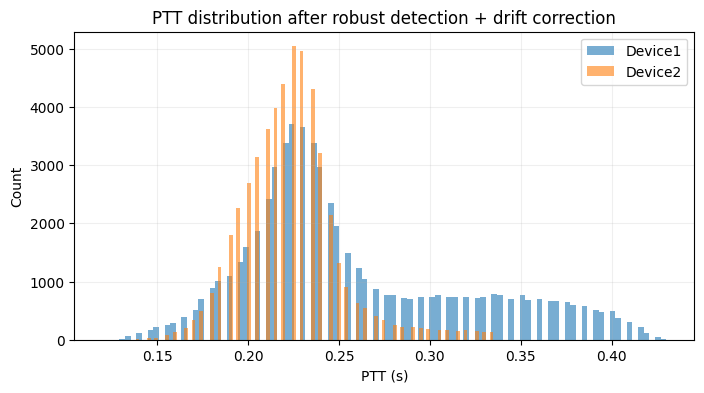

In [21]:
def ptt_summary(name, ptt):
    q = np.nanpercentile(ptt, [1, 5, 25, 50, 75, 95, 99])
    print(f"\n{name}")
    print("  min/max:", np.min(ptt), np.max(ptt))
    print("  p01,p05,p25,p50,p75,p95,p99:", q)

ptt_summary("Device1 (after)", ptt_after_clean)
ptt_summary("Device2 (after)", ptt_d2_clean)

plt.figure(figsize=(8,4))
plt.hist(ptt_after_clean, bins=100, alpha=0.6, label='Device1')
plt.hist(ptt_d2_clean, bins=100, alpha=0.6, label='Device2')
plt.xlabel("PTT (s)")
plt.ylabel("Count")
plt.title("PTT distribution after robust detection + drift correction")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### Interpretation checklist

If there are still issues after this fix, inspect these in order:
1. `map_device_1['a']` and `map_device_2['a']` should be close to 1 (small ppm drift).
2. `Slope after` should be much closer to zero than `Slope before`.
3. PTT distribution should cluster mostly in ~0.15-0.35 s (with some spread).
4. If PTT still piles at bounds 0.10 or 0.45, tighten motion filtering and/or revise expected delay.



Device1 (after)
  min/max: 0.12 0.43
  p01,p05,p25,p50,p75,p95,p99: [0.155 0.18  0.215 0.24  0.3   0.385 0.41 ]

Device2 (after)
  min/max: 0.13 0.335
  p01,p05,p25,p50,p75,p95,p99: [0.17  0.185 0.205 0.225 0.235 0.27  0.32 ]


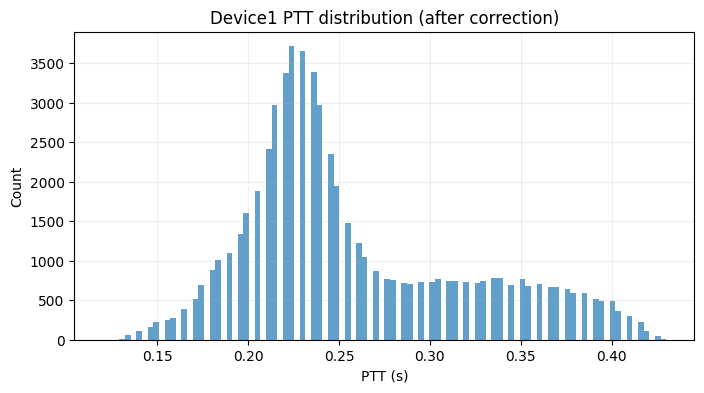

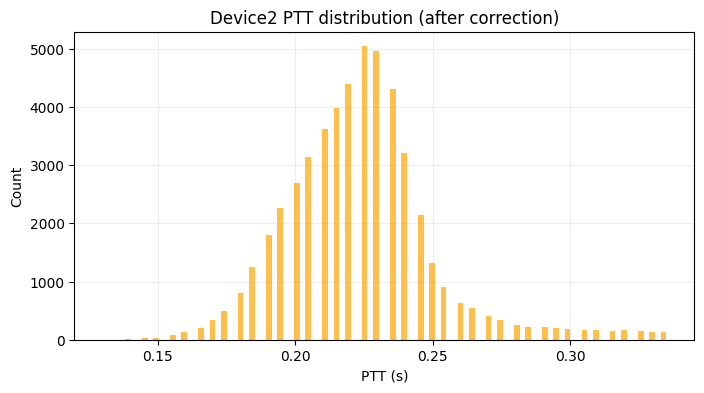

In [22]:
def ptt_summary(name, ptt):
    q = np.nanpercentile(ptt, [1, 5, 25, 50, 75, 95, 99])
    print(f"\n{name}")
    print("  min/max:", np.min(ptt), np.max(ptt))
    print("  p01,p05,p25,p50,p75,p95,p99:", q)

ptt_summary("Device1 (after)", ptt_after_clean)
ptt_summary("Device2 (after)", ptt_d2_clean)

# --- Device 1 ---
plt.figure(figsize=(8,4))
plt.hist(ptt_after_clean, bins=100, alpha=0.7)
plt.xlabel("PTT (s)")
plt.ylabel("Count")
plt.title("Device1 PTT distribution (after correction)")
plt.grid(alpha=0.2)
plt.show()

# --- Device 2 ---
plt.figure(figsize=(8,4))
plt.hist(ptt_d2_clean, bins=100, alpha=0.7, color="orange")
plt.xlabel("PTT (s)")
plt.ylabel("Count")
plt.title("Device2 PTT distribution (after correction)")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# Device 2: compute missing variables (if needed) and plot 60s segment-wise PTT trend
required_for_device2 = [
    "ppg_df_device_2", "ppg_clean_device_2", "ecg_df", "rpeaks", "fs_ecg",
    "ppg_idx_1_device_2", "ppg_idx_2_device_2", "ecg_idx_1", "ecg_idx_2",
]

missing_required = [name for name in required_for_device2 if name not in globals()]
if missing_required:
    print("Device 2 60s graph skipped: missing prerequisites:", missing_required)
    print("Run the Device 2 processing/setup cells first, then re-run this cell.")
else:
    # AFTER correction map + resampled signal (if not already available)
    if "ppg_resampled_device_2_stable" not in globals() or "map_device_2" not in globals():
        ppg_resampled_device_2_stable, map_device_2 = resample_ppg_to_ecg_domain_stable(
            ppg_df_device_2["time"].to_numpy(np.int64),
            ppg_clean_device_2,
            ecg_df["time"].to_numpy(np.int64),
            [ppg_idx_1_device_2, ppg_idx_2_device_2],
            [ecg_idx_1, ecg_idx_2],
        )

    # AFTER correction PTT (if not already available)
    if any(name not in globals() for name in ["ptt_d2_clean", "beat_time_d2"]):
        ppg_pk_d2, r_d2 = robust_ecg_guided_ppg_peaks(rpeaks, ppg_resampled_device_2_stable, fs_ecg)
        ptt_d2 = (ppg_pk_d2 - r_d2) / fs_ecg
        mask_d2 = mad_outlier_mask(ptt_d2, thresh=5.0)
        ptt_d2_clean = ptt_d2[mask_d2]
        beat_time_d2 = r_d2[mask_d2] / fs_ecg

    # BEFORE correction baseline PTT (if not already available)
    if any(name not in globals() for name in ["ptt_before_d2", "beat_time_before_d2"]):
        t_ppg2_abs = ppg_df_device_2["time"].to_numpy(np.int64) / 1e9
        t_ecg_abs = ecg_df["time"].to_numpy(np.int64) / 1e9
        ppg2_abs_to_ecg = np.interp(t_ecg_abs, t_ppg2_abs, ppg_clean_device_2)
        ppg_pk_before_d2, r_before_d2 = robust_ecg_guided_ppg_peaks(rpeaks, ppg2_abs_to_ecg, fs_ecg)
        ptt_before_d2 = (ppg_pk_before_d2 - r_before_d2) / fs_ecg
        beat_time_before_d2 = r_before_d2 / fs_ecg

    plot_segmentwise_ptt("Device 2", beat_time_before_d2, ptt_before_d2, beat_time_d2, ptt_d2_clean)
